<div style="text-align: center; padding: 20px; border-radius: 10px;">
    <h1 style="color: #dd2ebd;"><b>Sign Language Recognition</b></h1>
    <h3 style="color: #3498db;"><b>Using Deep Convolutional Neural Networks</b></h3>
    <p style="color: #056933; text-align: center;"><b>Phase 1: Exploratory Data Analysis</b></p>
    <p style="color: #f10fb5; font-size: 18px; font-weight: bold; text-align: center;">By: Fatemeh Behzadi Dil, Fatemeh Damirchi</p>
</div>

<h1 style="color: #4a5e04; font-size: 27px"><b>Introduction</b></h1>

<p style="font-size: 16px; line-height: 1.8;">
    Since a deep understanding of the dataset is fundamental to designing effective deep learning models, 
    this phase of our project is dedicated to a comprehensive 
    <span style="color: #09866d; font-weight: bold;">Exploratory Data Analysis (EDA)</span> 
    and 
    <span style="font-weight: bold;">preprocessing</span> 
    of the provided sign language image dataset. This stage is critical, as the quality and structure of 
    the input data directly influence the performance and reliability of the convolutional neural network 
    we will develop in subsequent phases.
</p>


<h2 style="color: #005d35; font-size: 22px"><b>1. Dataset Overview & Class Distribution Analysis</b></h2>

<p style="font-size: 16px; line-height: 1.8;">
    Our initial investigation focuses on thoroughly examining all components of the dataset to gain 
    valuable insights into its characteristics. We begin by analyzing the class distribution to determine 
    whether the dataset contains a 
    <span style="color: #085588; font-weight: bold;">balanced number of samples</span> 
    across all categories. This is particularly important in sign language recognition, where class 
    imbalance can lead to biased predictions and poor generalization for underrepresented letters or words.
</p>

<p style="font-size: 16px; line-height: 1.8;">
    To visualize this distribution, we generate a 
    <span style="color: #094369; font-weight: bold;">bar chart</span> 
    that clearly illustrates the number of samples per class, enabling us to quickly identify any potential 
    imbalances that may require corrective measures such as 
    <span style="color: #034570; font-weight: bold;">data augmentation</span> 
    or 
    <span style="color: #074c7a; font-weight: bold;">class weighting</span> 
    during model training.
</p>


In [4]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

print("All libraries imported successfully!")

All libraries imported successfully!


<h1 style="color: #da23a0; font-size: 27px"><b>1.1 Load Dataset & Explore Structure</b></h1>


In [5]:
from pathlib import Path

DATASET_PATH = Path("C:/Users/ASUS/Documents/alphabet")

TRAIN_PATH = DATASET_PATH / "asl_alphabet_train/asl_alphabet_train"

print("DATASET OVERVIEW")

print(f"\nTrain path exists: {TRAIN_PATH.exists()}")

if TRAIN_PATH.exists():
    train_classes = sorted([d.name for d in TRAIN_PATH.iterdir() if d.is_dir()])
    train_counts = {cls: len(list((TRAIN_PATH / cls).glob('*.*'))) for cls in train_classes}
    
    counts = list(train_counts.values())
    class_names = list(train_counts.keys())
    
    print(f"\nTRAIN SET:")
    print(f"   Classes: {len(train_classes)}")
    print(f"   Images:  {sum(counts):,}")
    print(f"   Min:     {min(counts)} (Class: {class_names[counts.index(min(counts))]})")
    print(f"   Max:     {max(counts)} (Class: {class_names[counts.index(max(counts))]})")
    print(f"   Mean:    {sum(counts) / len(counts):.0f}")
    
print(f"\nTotal: {sum(train_counts.values()):,} images")

DATASET OVERVIEW

Train path exists: True

TRAIN SET:
   Classes: 29
   Images:  87,000
   Min:     3000 (Class: A)
   Max:     3000 (Class: A)
   Mean:    3000

Total: 87,000 images


<h1 style="color: #da23a0; font-size: 27px"><b>1.2 Class Distribution Analysis</b></h1>


In [6]:
import pandas as pd
from pathlib import Path

def count_images_train(class_dir):
    counts = {}
    if class_dir.exists():
        for class_folder in class_dir.iterdir():
            if class_folder.is_dir():
                images = list(class_folder.glob("*"))
                counts[class_folder.name] = len(images)
    return pd.Series(counts).sort_index()

train_counts = count_images_train(TRAIN_PATH)

print("TRAIN SET")
print(f"Total images: {train_counts.sum():,}")
print(f"Number of classes: {len(train_counts)}")
print(f"Min: {train_counts.min()} (Class: {train_counts.idxmin()})")
print(f"Max: {train_counts.max()} (Class: {train_counts.idxmax()})")
print(f"Mean: {train_counts.mean():.0f}")

TRAIN SET
Total images: 87,000
Number of classes: 29
Min: 3000 (Class: A)
Max: 3000 (Class: A)
Mean: 3000


<h1 style="color: #e50c3b; font-size: 27px"><b>Analysis</b></h1>

As shown in the results, the training dataset contains 
<span style="color: #0c4367; font-weight: bold;">3,000 images per class</span> 
across all <span style="color: #004573; font-weight: bold;">29 classes</span>, 
making it <span style="color: #08883d; font-weight: bold;">perfectly balanced</span>. 

The test set contains <span style="color: #0f5b8f; font-weight: bold;">1 image per class</span> 
for <span style="color: #054d7e; font-weight: bold;">28 classes</span>, 
with the exception of the <span style="color: #e74c3c; font-weight: bold;">'del'</span> class 
which is not present in the test set. 

<span style="color: #027432; font-weight: bold;">Overall, the dataset is completely balanced and well-structured for model training.</span>

<h1 style="color: #da23a0; font-size: 27px"><b>1.2.1 Class Distribution Visualization</b></h1>


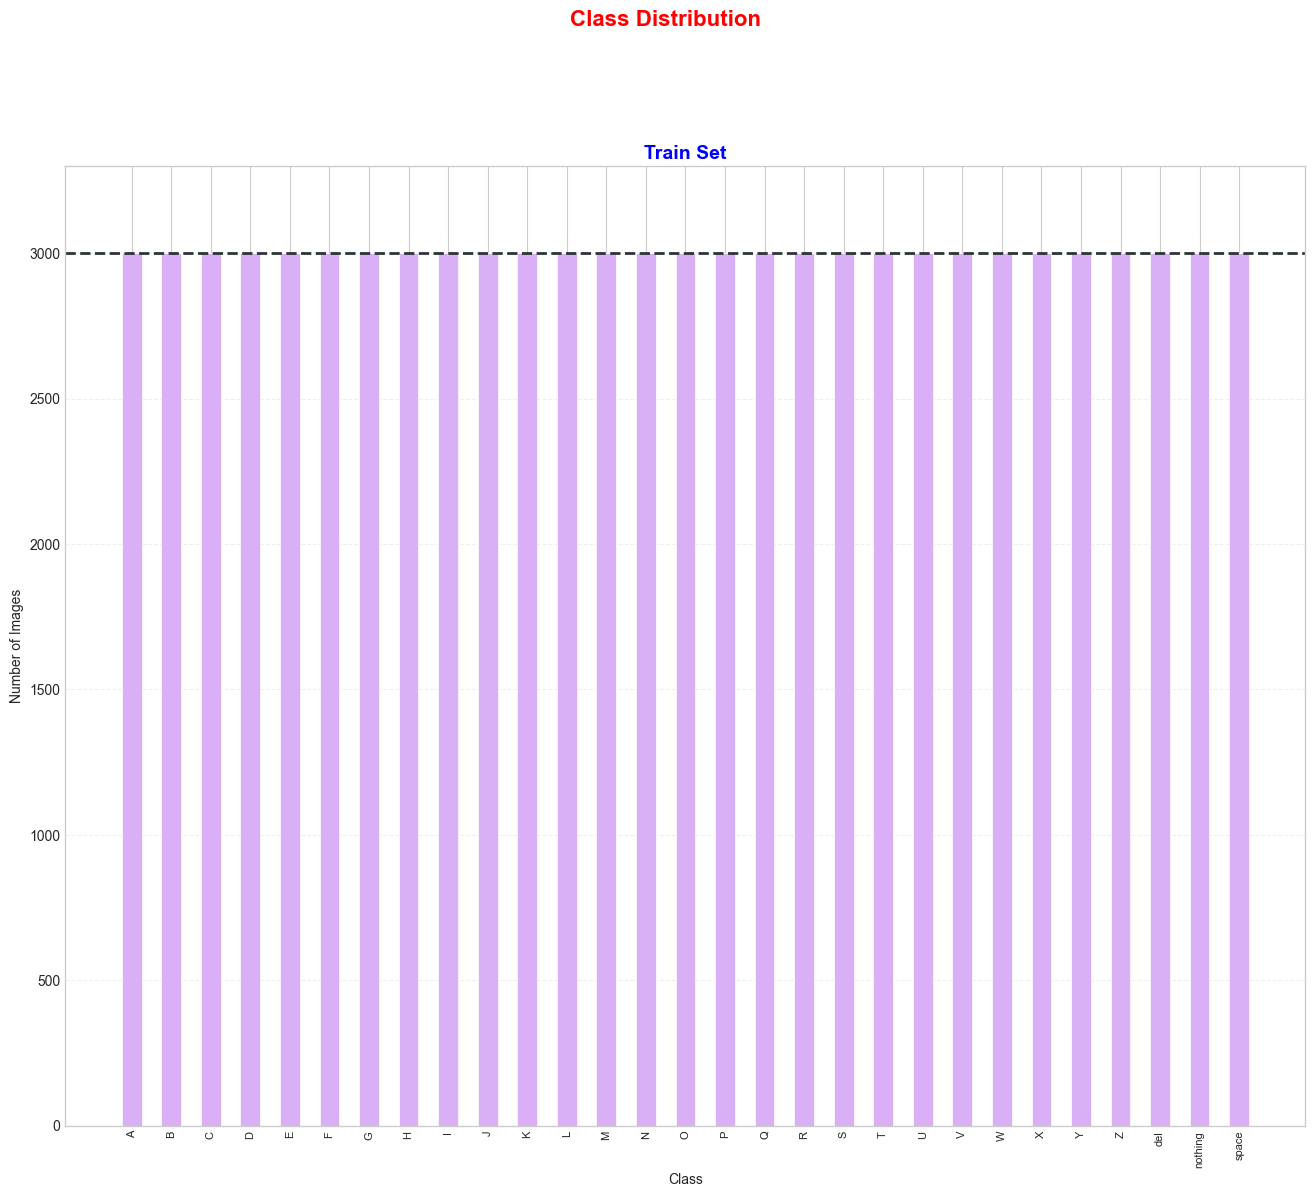

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

COLOR_TRAIN = '#d9aff6'
COLOR_TEST = '#67d6f9'  
COLOR_DEL = '#e74c3c' 
COLOR_LINE = '#2d3436'

all_classes = sorted(train_counts.index)

fig, axes = plt.subplots(1, 1, figsize=(16, 12))
fig.subplots_adjust(hspace=0.8, top=0.85, bottom=0.05)

axes.bar(train_counts.index, train_counts.values, color=COLOR_TRAIN, edgecolor='white', linewidth=0.5, width=0.5)
axes.axhline(y=train_counts.mean(), color=COLOR_LINE, linestyle='--', linewidth=2)
axes.set_title('Train Set', fontsize=14, color='blue', fontweight='bold', pad=5)
axes.set_xlabel('Class')
axes.set_ylabel('Number of Images')
axes.tick_params(axis='x', rotation=90, labelsize=8)
axes.set_ylim(0, train_counts.max() * 1.1)
axes.grid(axis='y', linestyle='--', alpha=0.3)


plt.suptitle('Class Distribution', fontsize=16, fontweight='bold', color='red', y=0.98)
plt.show()

<h1 style="color: #da23a0; font-size: 27px"><b>1.3 Visualize Sample Images</b></h1>


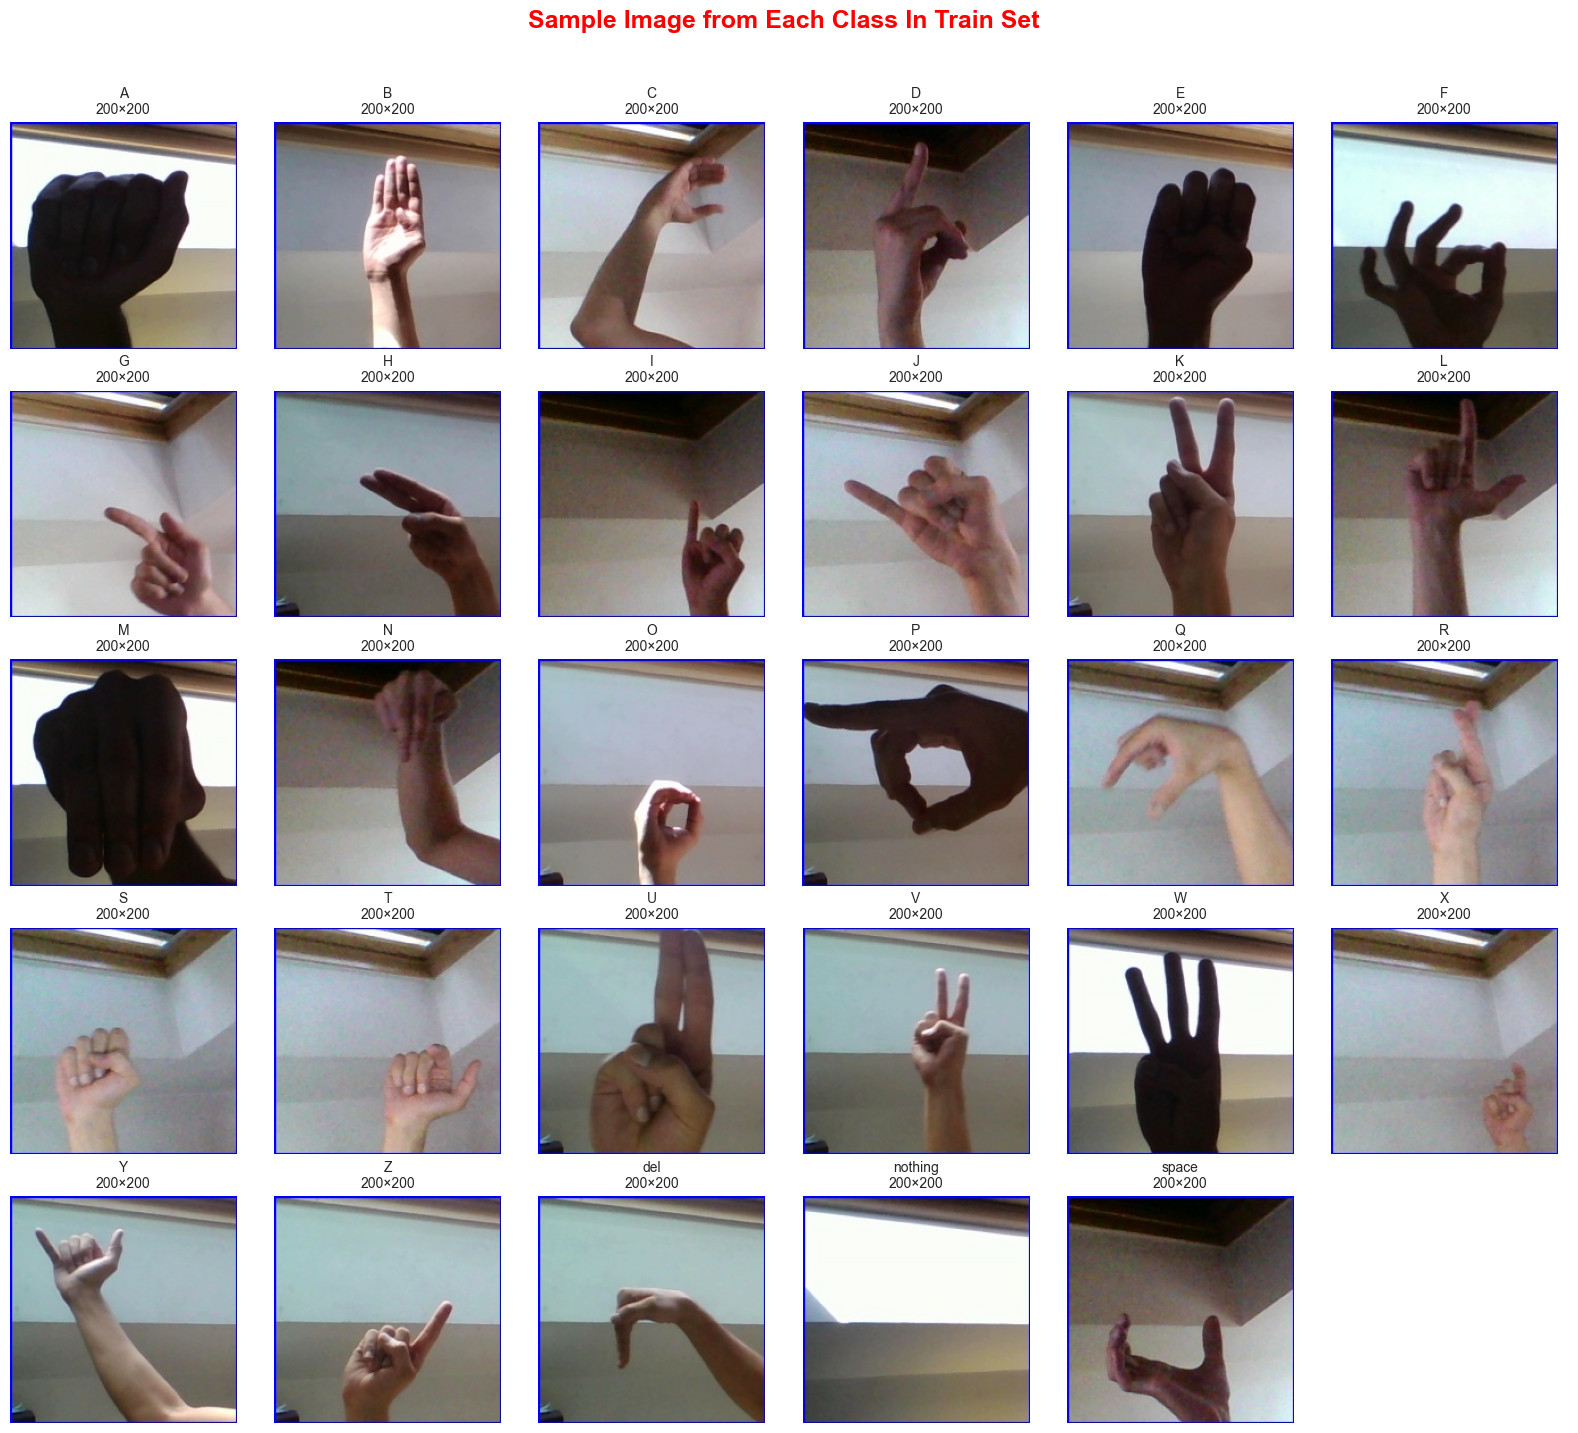

In [8]:
import random
fig, axes = plt.subplots(5, 6, figsize=(16, 14))
axes = axes.flatten()

class_names = sorted(train_counts.index.tolist())

for idx, class_name in enumerate(class_names):
    class_path = TRAIN_PATH / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.jpeg")) + list(class_path.glob("*.png"))
        if images:
            try:
                num_img = random.randint(0, len(images) - 1)
                img = Image.open(images[num_img])
                axes[idx].imshow(img)
                axes[idx].set_title(f'{class_name}\n{img.size[0]}×{img.size[1]}', fontsize=10)
            except Exception as e:
                axes[idx].set_title(f'{class_name}\n(Error loading)', fontsize=10)
        else:
            axes[idx].set_title(f'{class_name}\n(No images)', fontsize=10)
    else:
        axes[idx].set_title(f'{class_name}\n(Not found)', fontsize=10)
    axes[idx].axis('off')

for idx in range(len(class_names), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Sample Image from Each Class In Train Set', fontsize=18, color='red', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

<h1 style="color: #da23a0; font-size: 27px"><b>1.4 Image Properties Analysis</b></h1>


In [9]:
import random
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

sample_data = []
image_sizes = []
image_modes = []
aspect_ratios = []
total_images = 0

for class_name in class_names:
    class_path = TRAIN_PATH / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.jpeg")) + list(class_path.glob("*.png"))
        total_images += len(images)
        
        for img_path in images:
            try:
                with Image.open(img_path) as img:
                    width, height = img.size
                    image_sizes.append((width, height))
                    image_modes.append(img.mode)
                    aspect_ratios.append(width / height if height > 0 else 0)
                    sample_data.append({
                        'class': class_name,
                        'path': str(img_path),
                        'width': width,
                        'height': height,
                        'aspect_ratio': width / height if height > 0 else 0,
                        'mode': img.mode
                    })
            except Exception as e:
                print(f"⚠️ Error opening {img_path}: {e}")

df_props = pd.DataFrame(sample_data)

print(f"\nTotal images analyzed: {len(df_props):,}")

print(f"\nColor Mode Distribution:")
print(df_props['mode'].value_counts().to_string())

print(f"\nImage Size Statistics:")
print(f"   - Width:  Min={df_props['width'].min()}, Max={df_props['width'].max()}, Mean={df_props['width'].mean():.0f}, Std={df_props['width'].std():.0f}")
print(f"   - Height: Min={df_props['height'].min()}, Max={df_props['height'].max()}, Mean={df_props['height'].mean():.0f}, Std={df_props['height'].std():.0f}")

print(f"\nAspect Ratio Statistics:")
print(f"   - Min: {df_props['aspect_ratio'].min():.2f}")
print(f"   - Max: {df_props['aspect_ratio'].max():.2f}")
print(f"   - Mean: {df_props['aspect_ratio'].mean():.2f}")
print(f"   - Median: {df_props['aspect_ratio'].median():.2f}")
print(f"   - Std: {df_props['aspect_ratio'].std():.2f}")


Total images analyzed: 87,000

Color Mode Distribution:
mode
RGB    87000

Image Size Statistics:
   - Width:  Min=200, Max=200, Mean=200, Std=0
   - Height: Min=200, Max=200, Mean=200, Std=0

Aspect Ratio Statistics:
   - Min: 1.00
   - Max: 1.00
   - Mean: 1.00
   - Median: 1.00
   - Std: 0.00


<p style="color: #66098e; font-size: 16px; line-height: 1.8;">
    The results obtained from the image properties analysis reveal that the entire training dataset is 
    <span style="color: #d751c5; font-weight: bold;">perfectly uniform</span>. 
    All images share identical dimensions of 
    <span style="color: #0ec23b; font-weight: bold; padding: 2px 8px; border-radius: 5px;">200 × 200 pixels</span> 
    and are consistently formatted in the
    <span style="color: #e67e22; font-weight: bold; padding: 2px 8px; border-radius: 5px;">RGB color space</span>.
</p>

<p style="color: #66098e; font-size: 16px; line-height: 1.8;">
    This standardization eliminates the need for any resizing or color conversion during preprocessing, 
    which simplifies the data pipeline and ensures seamless compatibility with the neural network input layer.
</p>

<h1 style="color: #da23a0; font-size: 27px"><b>1.4.1 Pixel Value Normalization</b></h1>

Analyzing 5 sample images...

📊 Pixel Value Statistics (Raw - Before Normalization):
   - Min: 0
   - Max: 255
   - Mean: 115.02
   - Std: 63.29

📊 Pixel Value Statistics (After Normalization to [0,1]):
   - Min: 0.0000
   - Max: 1.0000
   - Mean: 0.4510
   - Std: 0.2482


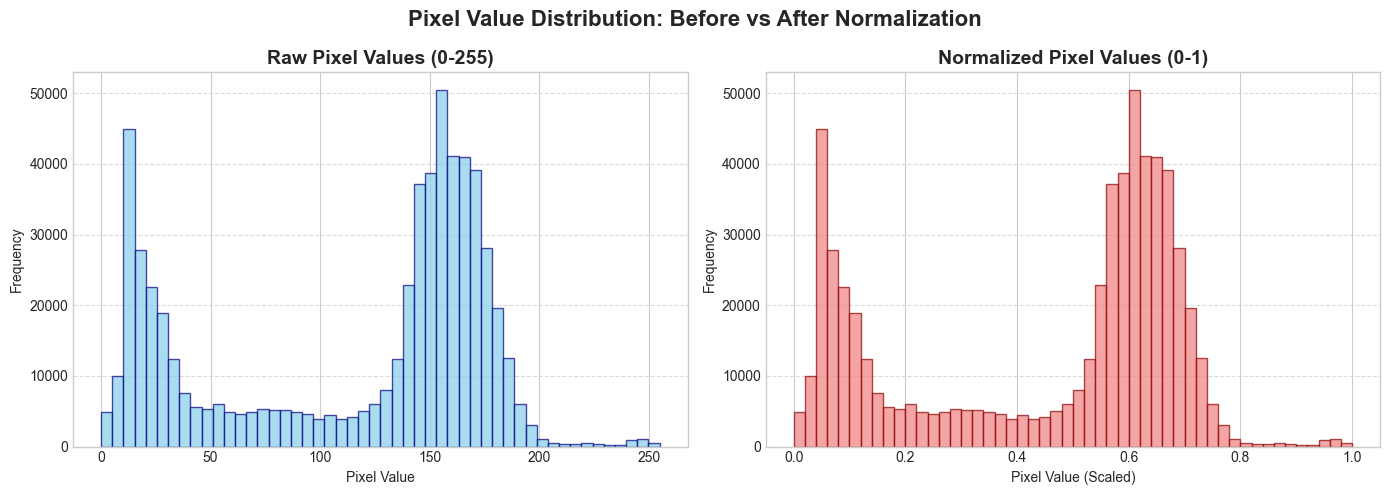

In [ ]:
import numpy as np
from PIL import Image

sample_paths = []
for class_name in train_classes[:5]: 
    class_path = TRAIN_PATH / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.jpeg")) + list(class_path.glob("*.png"))
        if images:
            sample_paths.append(images[0])

print(f"Analyzing {len(sample_paths)} sample images...")

pixel_values = []
for img_path in sample_paths:
    img = Image.open(img_path)
    img_array = np.array(img)
    pixel_values.extend(img_array.flatten())

pixel_values = np.array(pixel_values)

print(f"\n📊 Pixel Value Statistics (Raw - Before Normalization):")
print(f"   - Min: {pixel_values.min()}")
print(f"   - Max: {pixel_values.max()}")
print(f"   - Mean: {pixel_values.mean():.2f}")
print(f"   - Std: {pixel_values.std():.2f}")

normalized_values = pixel_values / 255.0
print(f"\n📊 Pixel Value Statistics (After Normalization to [0,1]):")
print(f"   - Min: {normalized_values.min():.4f}")
print(f"   - Max: {normalized_values.max():.4f}")
print(f"   - Mean: {normalized_values.mean():.4f}")
print(f"   - Std: {normalized_values.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pixel_values, bins=50, color='skyblue', edgecolor='navy', alpha=0.7)
axes[0].set_title('Raw Pixel Values (0-255)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pixel Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

axes[1].hist(normalized_values, bins=50, color='lightcoral', edgecolor='darkred', alpha=0.7)
axes[1].set_title('Normalized Pixel Values (0-1)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pixel Value (Scaled)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Pixel Value Distribution: Before vs After Normalization', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<h1 style="color: #da23a0; font-size: 27px"><b>1.5 Splitting Data</b></h1>


In [14]:
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split

DATASET_PATH = Path("C:/Users/ASUS/Documents/alphabet")

TRAIN_PATH = DATASET_PATH / "asl_alphabet_train" / "asl_alphabet_train"
TEST_PATH = DATASET_PATH / "asl_alphabet_test" / "asl_alphabet_test"

NEW_TRAIN_DIR = DATASET_PATH / "train_new"
VAL_DIR = DATASET_PATH / "val"
TEST_NEW_DIR = DATASET_PATH / "test_new"

for folder in [NEW_TRAIN_DIR, VAL_DIR, TEST_NEW_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Folders created")
print(f"   Train: {NEW_TRAIN_DIR}")
print(f"   Val:   {VAL_DIR}")
print(f"   Test:  {TEST_NEW_DIR}")

total_train = 0
total_val = 0
total_test = 0

for class_folder in TRAIN_PATH.iterdir():
    if not class_folder.is_dir():
        continue
    
    class_name = class_folder.name
    images = list(class_folder.glob("*.jpg")) + list(class_folder.glob("*.jpeg")) + list(class_folder.glob("*.png"))
    
    if not images:
        print(f"⚠️ No images in {class_name}")
        continue
    
    train_imgs, temp_imgs = train_test_split(
        images, 
        test_size=0.25, 
        random_state=42
    )
    
    val_imgs, test_imgs = train_test_split(
        temp_imgs, 
        test_size=0.4, 
        random_state=42
    )
    
    for target_dir, img_list in [
        (NEW_TRAIN_DIR, train_imgs),
        (VAL_DIR, val_imgs),
        (TEST_NEW_DIR, test_imgs)
    ]:
        target_class_dir = target_dir / class_name
        target_class_dir.mkdir(exist_ok=True)
        
        for img_path in img_list:
            shutil.copy2(img_path, target_class_dir / img_path.name)
    
    total_train += len(train_imgs)
    total_val += len(val_imgs)
    total_test += len(test_imgs)
    
    print(f"{class_name:>10}: Train={len(train_imgs):>5}, Val={len(val_imgs):>5}, Test={len(test_imgs):>5}")

print("="*60)
print("✅ Split complete!")
print(f"Total train: {total_train:,} images ({total_train/(total_train+total_val+total_test)*100:.1f}%)")
print(f"Total val: {total_val:,} images ({total_val/(total_train+total_val+total_test)*100:.1f}%)")
print(f"Total test: {total_test:,} images ({total_test/(total_train+total_val+total_test)*100:.1f}%)")
print(f"Grand total: {total_train + total_val + total_test:,} images")

✅ Folders created
   Train: C:\Users\ASUS\Documents\alphabet\train_new
   Val:   C:\Users\ASUS\Documents\alphabet\val
   Test:  C:\Users\ASUS\Documents\alphabet\test_new
         A: Train= 2250, Val=  450, Test=  300
         B: Train= 2250, Val=  450, Test=  300
         C: Train= 2250, Val=  450, Test=  300
         D: Train= 2250, Val=  450, Test=  300
       del: Train= 2250, Val=  450, Test=  300
         E: Train= 2250, Val=  450, Test=  300
         F: Train= 2250, Val=  450, Test=  300
         G: Train= 2250, Val=  450, Test=  300
         H: Train= 2250, Val=  450, Test=  300
         I: Train= 2250, Val=  450, Test=  300
         J: Train= 2250, Val=  450, Test=  300
         K: Train= 2250, Val=  450, Test=  300
         L: Train= 2250, Val=  450, Test=  300
         M: Train= 2250, Val=  450, Test=  300
         N: Train= 2250, Val=  450, Test=  300
   nothing: Train= 2250, Val=  450, Test=  300
         O: Train= 2250, Val=  450, Test=  300
         P: Train= 2250, Val=  

<h1 style="color: #da23a0; font-size: 27px"><b>1.5 Summary</b></h1>
The exploratory data analysis performed on the sign language dataset reveals several key characteristics that confirm the quality and suitability of the data for deep learning applications.

**Class Distribution:**  
The training set consists of <span style="color: #2980b9; font-weight: bold;">29 distinct classes</span>, with each class containing exactly <span style="color: #27ae60; font-weight: bold;">3,000 images</span>, making the dataset <span style="color: #27ae60; font-weight: bold;">perfectly balanced</span>. This equilibrium is essential for avoiding model bias and promoting equitable learning across all categories. 

**Image Standardization:**  
All images are uniformly sized at <span style="color: #2980b9; font-weight: bold;">200×200 pixels</span> and consistently follow the <span style="color: #2980b9; font-weight: bold;">RGB color format</span>. This consistency removes the need for resizing or color space transformations during preprocessing, greatly streamlining the pipeline and ensuring smooth integration with convolutional neural networks.

<h1 style="color: #905604; font-size: 27px"><b>Phase 2</b></h1>

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tqdm import tqdm

CLASSES_NUM = 29
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


<h1 style="color: #1063c9; font-size: 27px"><b>2.1 Designing Model Architecture</b></h1>

In [6]:
class SignLanguageCNN(nn.Module):
    def __init__(self, num_classes=29):
        super(SignLanguageCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(p=0.5)
        
        self.fully_connected1 = nn.Linear(256 * 12 * 12, 512)
        self.fully_connected2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fully_connected1(x))
        x = self.dropout(x)
        x = self.fully_connected2(x)
        return x

model = SignLanguageCNN(num_classes=29).to(DEVICE)
print(f"Model created")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Model created
Parameters: 19,278,173


<h1 style="color: #1063c9; font-size: 27px"><b>2.2 Data Loaders</b></h1>

<h1 style="color: #04502f; font-size: 22px;"><b>2.2 Calculating Mean and Standard Deviation</b></h1>

<p>After loading the dataset, we calculate the <b>mean</b> and <b>standard deviation</b> of pixel values across all training images. These statistics are essential for normalizing the data before feeding it into the neural network.</p>

<p><b>Mean</b> represents the average pixel value for each channel (Red, Green, Blue). It gives us an idea of the overall brightness and color balance of the dataset.</p>

<p><b>Standard Deviation</b> measures how much the pixel values deviate from the mean. A higher standard deviation indicates more variation in pixel intensities, while a lower value suggests more uniformity.</p>

<p>Using these values, we can normalize the images to have <b>zero mean</b> and <b>unit variance</b>, which helps the model converge faster and perform more effectively during training.</p>

In [9]:
DATASET_PATH = Path("C:/Users/ASUS/Documents/alphabet")
TRAIN_DIR = DATASET_PATH / "train_new"
VAL_DIR = DATASET_PATH / "val"
TEST_DIR = DATASET_PATH / "test_new"

# all images are in 200*200 but to be sure i transform all of them in 200*200
# and all pixels in [0,1]
transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=4)

mean = torch.zeros(3) #tensor with 3 factor. initialization with 0,0,0 (R,G,B)
std = torch.zeros(3) #tensor with 3 factor. initialization with 0,0,0 (R,G,B)
image_counter = 0 # number of images processed

for batch, hh in tqdm(loader):
    batch_size = batch.size(0)
    batch = batch.view(batch_size, 3, -1)
    mean += batch.mean(2).sum(0)
    std += batch.std(2).sum(0)
    image_counter += batch_size

mean /= image_counter
std /= image_counter

print("Mean:", mean.tolist())
print("Std:", std.tolist())

100%|██████████| 1020/1020 [02:41<00:00,  6.32it/s]

Mean: [0.518834114074707, 0.49898985028266907, 0.5144101977348328]
Std: [0.20458196103572845, 0.2336411476135254, 0.24120348691940308]


In [44]:
torch.save({'mean': mean, 'std': std}, 'dataset_stats.pt')
print("✅ Mean and Std saved to 'dataset_stats.pt'")

✅ Mean and Std saved to 'dataset_stats.pt'


In [10]:
transform_train = transforms.Compose([
    transforms.Resize((200, 200)), # we had it in previous code but repeat it again to be sure about it
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform_val = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print("Transforms done")

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform_train)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform_val)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=transform_val)

print(f"Train: {len(train_dataset):,} images")
print(f"Validation:   {len(val_dataset):,} images")
print(f"Test:  {len(test_dataset):,} images")
print(f"Classes: {train_dataset.classes}")

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Done")

Transforms done
Train: 65,250 images
Validation:   13,050 images
Test:  8,700 images
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
Done


In [9]:
NUM_EPOCHS = 10
BATCH_SIZE = 64
LEARNING_RATE = 0.001
CLASSES_NUM = 29
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "final_model.pth"

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5, verbose=True
)

c:\Users\ASUS\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [11]:
best_accuracy = 0.0
best_accuracy = 0.0
SAVE_PATH = "final_model.pth"

print(f"\nStart Training\n")

for epoch in range(1, NUM_EPOCHS + 1):
    
    model.train()
    train_loss_sum = 0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss_sum += loss.item()
        kk, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    train_loss_avg = train_loss_sum / len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    
    model.eval()
    val_loss_sum = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            val_loss_sum += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_loss_avg = val_loss_sum / len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    
    lr_scheduler.step(val_loss_avg)
    
    print(f"Epoch {epoch:2d}")
    print(f"Training accuracy: {train_accuracy:.2f}%")
    print(f"Validation accuracy: {val_accuracy:.2f}%\n")
    
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Model saved successfully with validation accuracy: {best_accuracy:.2f}%")


Start Training

Epoch  1
Training accuracy: 79.39%
Validation accuracy: 93.24%

Model saved successfully with validation accuracy: 93.24%
Epoch  2
Training accuracy: 87.02%
Validation accuracy: 96.35%

Model saved successfully with validation accuracy: 96.35%
Epoch  3
Training accuracy: 90.20%
Validation accuracy: 97.36%

Model saved successfully with validation accuracy: 97.36%
Epoch  4
Training accuracy: 92.05%
Validation accuracy: 98.01%

Model saved successfully with validation accuracy: 98.01%
Epoch  5
Training accuracy: 93.38%
Validation accuracy: 98.80%

Model saved successfully with validation accuracy: 98.80%
Epoch  6
Training accuracy: 94.14%
Validation accuracy: 98.79%

Epoch  7
Training accuracy: 94.72%
Validation accuracy: 98.70%

Epoch  8
Training accuracy: 95.29%
Validation accuracy: 98.57%

Epoch  9
Training accuracy: 95.79%
Validation accuracy: 99.23%

Model saved successfully with validation accuracy: 99.23%
Epoch 10
Training accuracy: 95.88%
Validation accuracy: 98.

In [40]:
SAVE_PATH = "final_model.pth"
model.load_state_dict(torch.load(SAVE_PATH))
print("Model loaded successfully!")

model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []
all_confidences = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = probabilities.max(1)
        
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_confidences.extend(confidence.cpu().numpy())

acc = 100. * correct / total
print(f"Test Accuracy: {acc:.2f}% ({correct}/{total})")

print(f"\nAverage Confidence: {np.mean(all_confidences) * 100:.2f}%")
print(f"Min Confidence:     {np.min(all_confidences) * 100:.2f}%")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_12600\1532896985.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(SAVE_PATH))


Model loaded successfully!
Test Accuracy: 99.34% (8643/8700)

Average Confidence: 98.98%
Min Confidence:     38.06%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002B602098360>
Traceback (most recent call last):
  File "c:\Users\ASUS\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torch\utils\data\dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "c:\Users\ASUS\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\torch\utils\data\dataloader.py", line 1562, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
                                   ^^^^^^^^^^^^^^^^^^^^
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


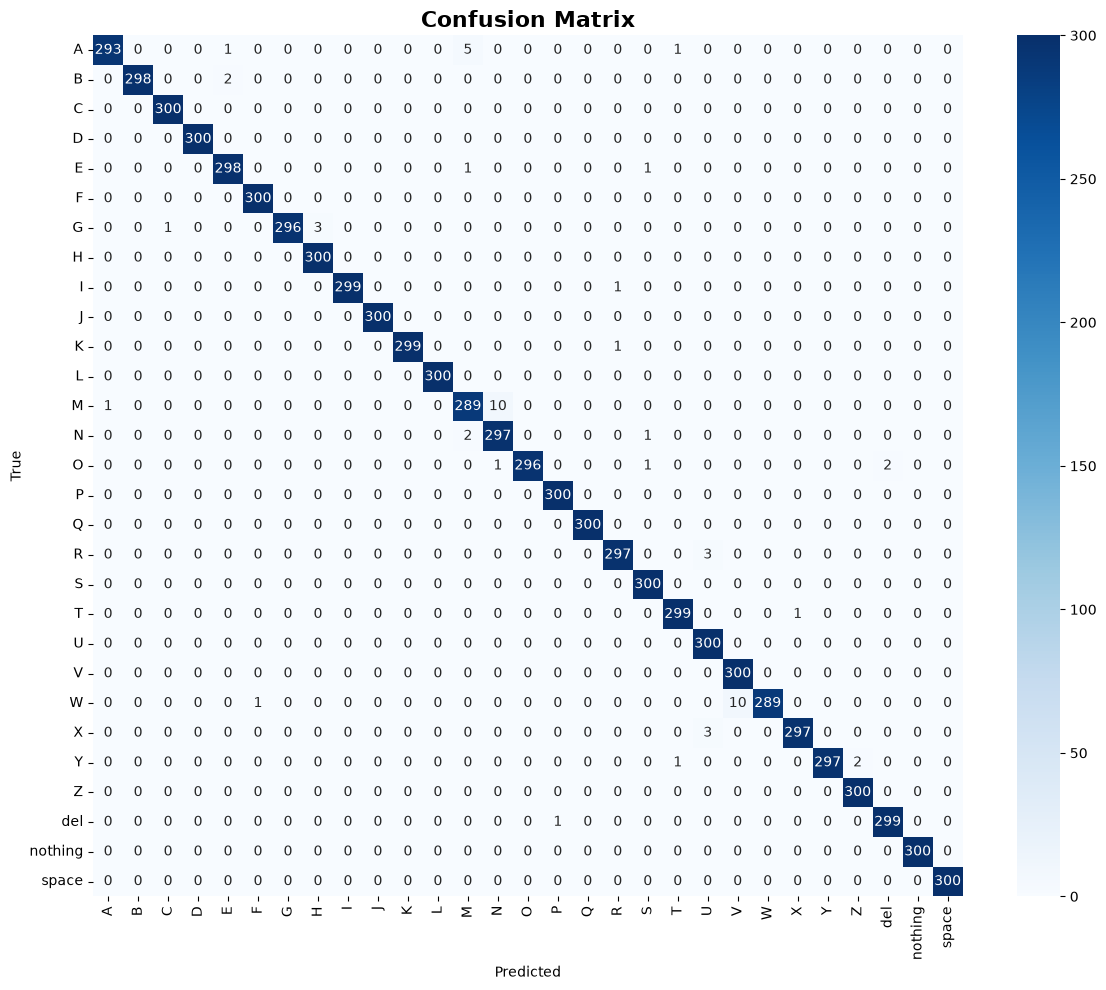


Most Confused Pairs:
   M → N: 10 times
   W → V: 10 times
   A → M: 5 times
   G → H: 3 times
   R → U: 3 times

Confusion Matrix Statistics:
   Total misclassified: 57 out of 8700 images
   Percentage: 0.66%


In [41]:
cm = confusion_matrix(all_labels, all_preds)
class_names = test_dataset.classes

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

misclassified = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            misclassified.append((class_names[i], class_names[j], cm[i][j]))

misclassified.sort(key=lambda x: x[2], reverse=True)

print("\nMost Confused Pairs:")
if misclassified:
    for true_class, pred_class, count in misclassified[:5]:
        print(f"   {true_class} → {pred_class}: {count} times")
else:
    print("   No misclassifications found!")

print("\nConfusion Matrix Statistics:")
print(f"   Total misclassified: {np.sum(cm) - np.trace(cm)} out of {np.sum(cm)} images")
print(f"   Percentage: {(np.sum(cm) - np.trace(cm)) / np.sum(cm) * 100:.2f}%")

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from pathlib import Path

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_PATH = "final_model.pth"
print(f"Device: {DEVICE}")

stats = torch.load('dataset_stats.pt')
mean = stats['mean']
std = stats['std']

print(f"Mean: {mean}")
print(f"Std: {std}")

transform = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 
               'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 
               'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


class SignLanguageCNN(nn.Module):
    def __init__(self, num_classes=29):
        super(SignLanguageCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.dropout = nn.Dropout(p=0.5)
        
        self.fully_connected1 = nn.Linear(256 * 12 * 12, 512)
        self.fully_connected2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.fully_connected1(x))
        x = self.dropout(x)
        x = self.fully_connected2(x)
        return x

model = SignLanguageCNN(num_classes=29).to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()
print("Model loaded successfully!")

Device: cuda
Mean: [0.4872, 0.4568, 0.4064]
Std: [0.2291, 0.2242, 0.2253]


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12600\448022781.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  stats = torch.load('dataset_stats.pt')
C:\Users\ASUS\AppData\

Model loaded successfully!


In [47]:
def predict_by_model(image_path):
    from PIL import Image
    
    img = Image.open(image_path).convert('RGB')
    img = transform_val(img).unsqueeze(0).to(DEVICE)
    
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        probabilities = F.softmax(outputs, dim=1)
        confidence, predicted = probabilities.max(1)
    
    class_name = class_names[predicted.item()]
    confidence_percent = confidence.item() * 100
    
    print(f"Predicted: {class_name}")
    print(f"Confidence: {confidence_percent:.2f}%")
    return class_name, confidence_percent

image_path = "C:/Users/ASUS/Documents/alphabet/test_new/L/L199.jpg"
predict_by_model(image_path)

Predicted: L
Confidence: 100.00%


('L', 100.0)